# Pronóstico de Generación Solar - Planta "El Paso"

# Contexto de los Datos: XM (Generación Real)

Basándonos en la documentación del proyecto, los datos de generación provienen de **XM**, el operador del Sistema Interconectado Nacional (SIN) en Colombia. Estos registros representan la "verdad de campo" (ground truth) obtenida mediante sensores de medición directa instalados en la planta solar **"El Paso"**.

### Detalles del Dataset:
- **Fuente**: XM (Telemedida directa).
- **Rango Temporal**: 2019-01-01 a 2023-12-31.
- **Resolución**: Horaria (24 columnas de generación por cada día).
- **Unidad**: kWh.

El archivo de datos de XM ya existe localmente.
Generando visualizaciones...


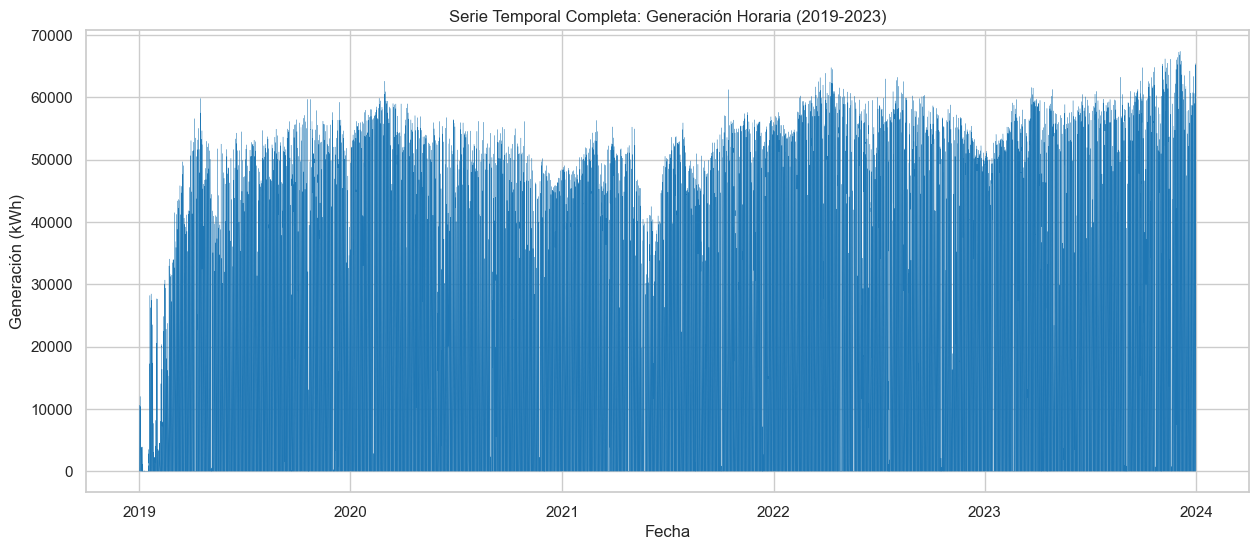

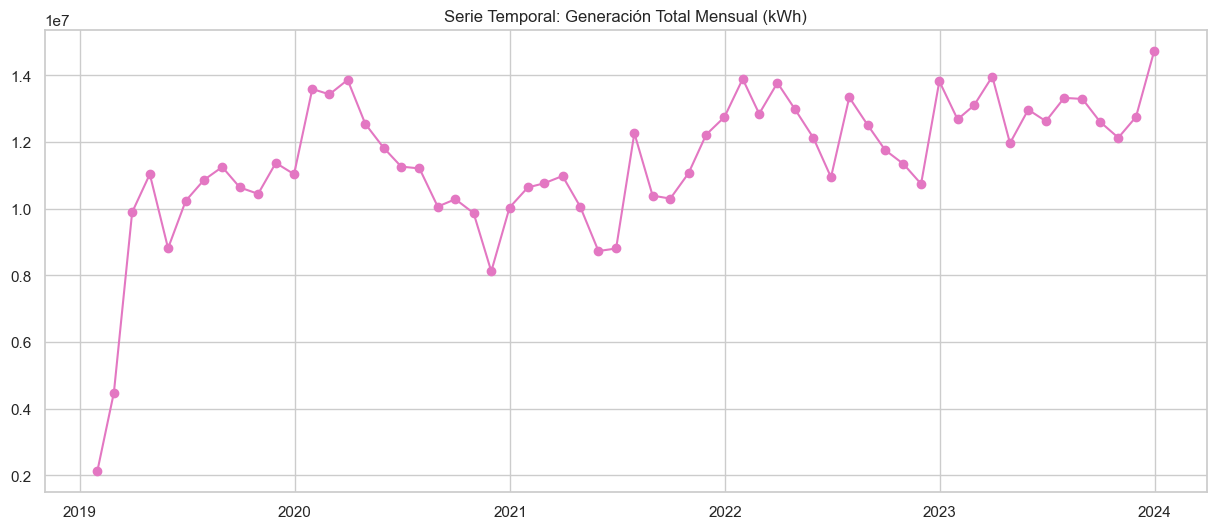

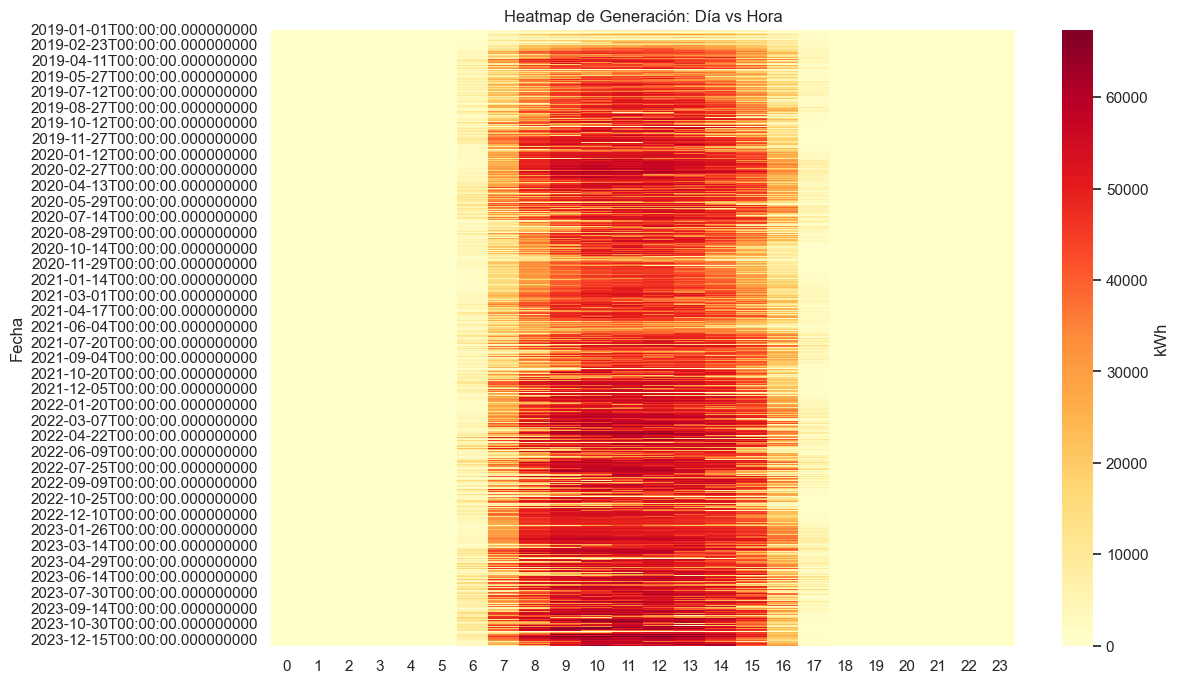

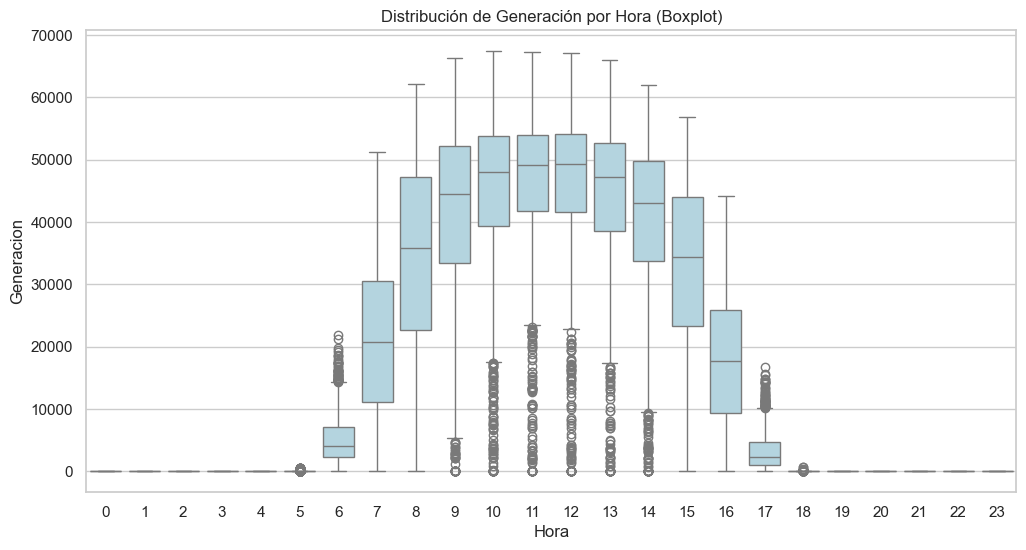

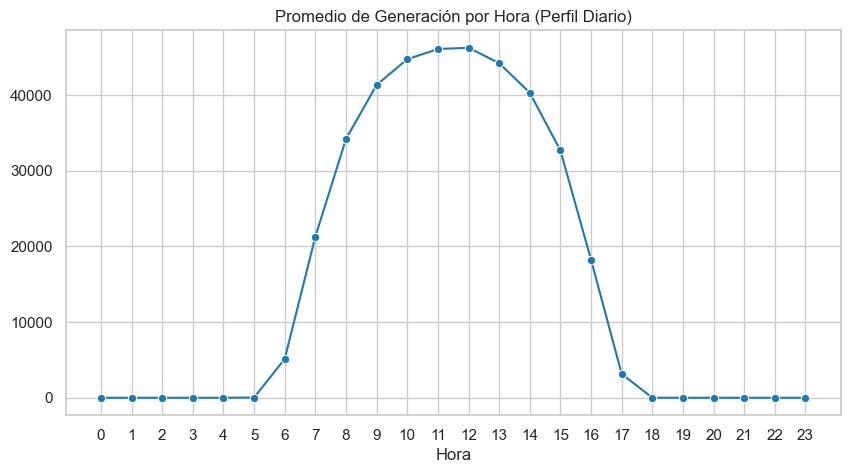

In [11]:
# Descarga de datos desde Google Drive
file_id = '1XM7xrH4WCh1knxF7kTt9Mj3mx1RUGnWC'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
csv_path = os.path.join(DATA_DIR, 'data_2019_2023_kwH_xm.csv')

if not os.path.exists(csv_path):
    print(f"Descargando datos de XM desde Google Drive...")
    try:
        response = requests.get(url)
        with open(csv_path, 'wb') as f:
            f.write(response.content)
        print("Descarga completada.")
    except Exception as e:
        print(f"Error en la descarga: {e}")
else:
    print("El archivo de datos de XM ya existe localmente.")

# Carga y Procesamiento
df = pd.read_csv(csv_path)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='mixed')
hours = [str(i) for i in range(24)]

# Transformación a formato largo (melted) para análisis
df_melted = df.melt(id_vars=['Fecha'], value_vars=hours, var_name='Hora', value_name='Generacion')
df_melted['Hora'] = df_melted['Hora'].astype(int)
df_melted['Timestamp'] = df_melted['Fecha'] + pd.to_timedelta(df_melted['Hora'], unit='h')
df_melted = df_melted.sort_values('Timestamp').reset_index(drop=True)

# Generación de Gráficas Solicitadas
output_xm_dir = os.path.join(EDA_DIR, 'XM')
os.makedirs(output_xm_dir, exist_ok=True)

print("Generando visualizaciones...")

# 1. Serie temporal completa (Horaria)
plt.figure(figsize=(15, 6))
plt.plot(df_melted['Timestamp'], df_melted['Generacion'], color='#1f77b4', linewidth=0.2)
plt.title('Serie Temporal Completa: Generación Horaria (2019-2023)')
plt.xlabel('Fecha')
plt.ylabel('Generación (kWh)')
plt.savefig(os.path.join(output_xm_dir, 'serie_temporal_completa.png'))
plt.show()

# 2. Serie temporal mensual (Suma total)
df_monthly = df_melted.set_index('Timestamp')['Generacion'].resample('ME').sum().reset_index()
plt.figure(figsize=(15, 6))
plt.plot(df_monthly['Timestamp'], df_monthly['Generacion'], marker='o', color='#e377c2')
plt.title('Serie Temporal: Generación Total Mensual (kWh)')
plt.savefig(os.path.join(output_xm_dir, 'serie_temporal_mensual_total.png'))
plt.show()

# 3. Heatmap día vs hora
heatmap_data = df.set_index('Fecha')[hours].astype(float)
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', cbar_kws={'label': 'kWh'})
plt.title('Heatmap de Generación: Día vs Hora')
plt.savefig(os.path.join(output_xm_dir, 'heatmap_dia_vs_hora.png'))
plt.show()

# 4. Boxplot por hora
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x='Hora', y='Generacion', color='lightblue')
plt.title('Distribución de Generación por Hora (Boxplot)')
plt.savefig(os.path.join(output_xm_dir, 'boxplot_generacion_hora.png'))
plt.show()

# 5. Promedio de generación por hora (Perfil Diario)
promedio_hora = df_melted.groupby('Hora')['Generacion'].mean()
plt.figure(figsize=(10, 5))
sns.lineplot(x=promedio_hora.index, y=promedio_hora.values, marker="o", color="#1f77b4")
plt.title('Promedio de Generación por Hora (Perfil Diario)')
plt.xticks(range(24))
plt.savefig(os.path.join(output_xm_dir, 'promedio_generacion_hora.png'))
plt.show()


### Análisis de las Visualizaciones
1. **Serie Temporal Completa**: Muestra la evolución horaria de la generación a lo largo de 5 años, permitiendo observar la consistencia del recurso.
2. **Serie Temporal Mensual**: Facilita la observación de la estacionalidad anual en la planta solar.
3. **Heatmap Día vs Hora**: Permite identificar patrones de generación a lo largo del día y posibles fallos o mantenimientos en fechas específicas.
4. **Boxplot por Hora**: Muestra la variabilidad de la generación en cada hora específica, resaltando la incertidumbre climática.
5. **Promedio de Generación por Hora**: Define el perfil típico de generación de la planta, confirmando la campana de producción solar.

### Metodología: Ventana Diurna
Como se observa en el perfil diario, la generación significativa ocurre entre las **06:00 AM y las 05:00 PM**. Por ello, el pipeline utiliza este filtro de 12 horas diarias para optimizar el entrenamiento de los modelos, eliminando los periodos nocturnos de generación nula que podrían sesgar las métricas.

## Paso 2: Análisis de Correlación NASA-XM

--- Iniciando Análisis de Correlación NASA-XM ---


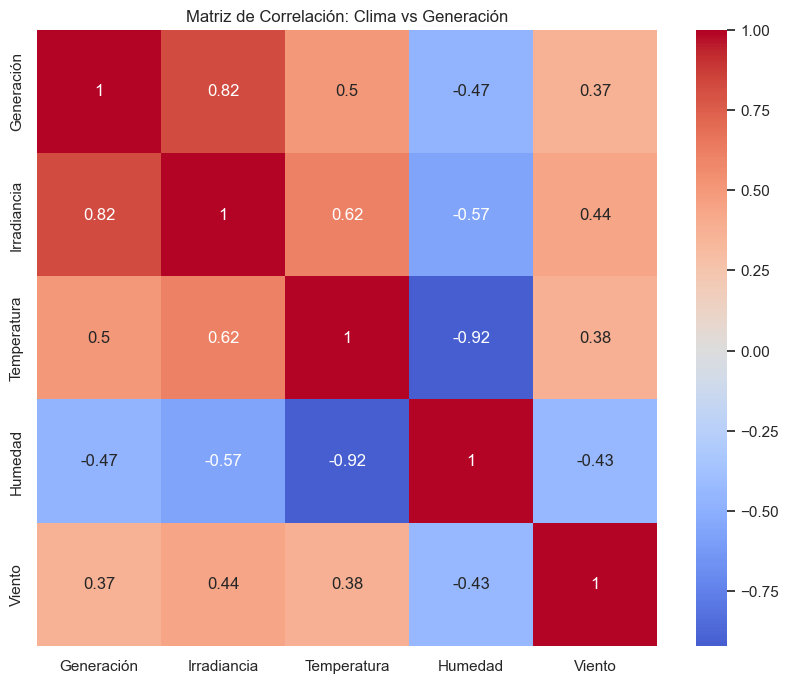

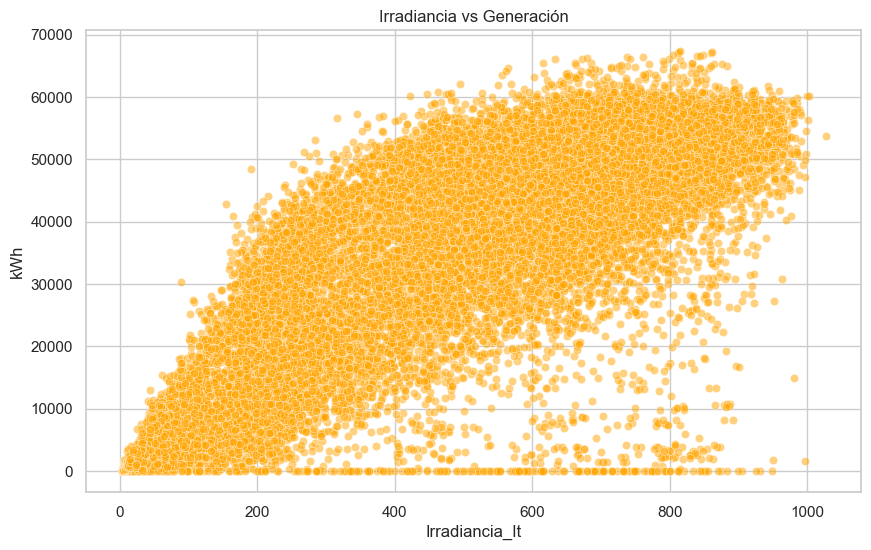

In [12]:
print("--- Iniciando Análisis de Correlación NASA-XM ---")
data_path = os.path.join(DATA_DIR, 'data-hourly.csv')
output_dir = os.path.join(EDA_DIR, 'NASA_xm_correlation')

df_corr_raw = pd.read_csv(data_path)
cols = {'kWh': 'Generación', 'Irradiancia_It': 'Irradiancia', 'Temperatura_Tt': 'Temperatura', 'Humedad_Ht': 'Humedad', 'Viento_Wt': 'Viento'}
df_corr = df_corr_raw[list(cols.keys())].rename(columns=cols)

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", center=0)
plt.title('Matriz de Correlación: Clima vs Generación')
plt.savefig(os.path.join(output_dir, '1_1_heatmap_correlacion.png'))
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_corr_raw, x='Irradiancia_It', y='kWh', alpha=0.5, color='orange')
plt.title('Irradiancia vs Generación')
plt.savefig(os.path.join(output_dir, 'scatter_irradiancia_vs_generacion.png'))
plt.show()